# Week 8 Assignment #6: Exploratory Data Analysis
Student: Daniel Foulen

Class: IS 362

Date: 3/21/2026

## Overview

In this assignment, we load the Auto MPG dataset from the UC Irvine Machine Learning Repository.

We perform light data cleaning and transformation, then use exploratory data analysis (EDA) to visualize distributions and relationships between variables.

Steps:
1. Load the dataset into a pandas DataFrame with proper column names
2. Confirm horsepower cleaning and column types
3. Convert the origin column from numeric codes to region labels
4. Bar chart: distribution of cylinder counts
5. Scatterplot: horsepower vs. weight
6. Original question + answer using matplotlib/seaborn

## Step 1: Load the Data

The dataset is hosted at the UCI repository. It is whitespace-separated with no header row.

A standard `pd.read_csv` with `sep=r'\s+'` fails on this file because car names contain spaces (e.g. "chevrolet chevelle malibu"), which the whitespace separator splits into extra fields, causing a column count mismatch.

Instead, we fetch the raw text and use Python's `str.split(None, 8)`, which splits on whitespace a maximum of 8 times. This preserves multi-word car names as a single field.

Missing horsepower values marked as '?' are replaced with NaN at load time, and all numeric columns are converted using `pd.to_numeric`.

Column names come from `auto-mpg.names`:
mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin, car_name

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

col_names = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin', 'car_name'
]

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

# Fetch raw text and split each line on whitespace a maximum of 8 times
# This preserves multi-word car names (e.g. "ford pinto") as a single field
response = requests.get(url)
lines = response.text.strip().split('\n')
rows = [line.split(None, 8) for line in lines if line.strip()]

df = pd.DataFrame(rows, columns=col_names)

# Replace '?' with NaN and convert all numeric columns
df.replace('?', np.nan, inplace=True)

numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower',
                'weight', 'acceleration', 'model_year', 'origin']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,"""chevrolet chevelle malibu"""
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,"""buick skylark 320"""
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,"""plymouth satellite"""
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,"""amc rebel sst"""
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,"""ford torino"""


## Step 2: Inspect the Data

Before proceeding, we review the shape, data types, and missing value counts to confirm the data loaded correctly.

In [2]:
# Shape: rows and columns
df.shape

(398, 9)

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [4]:
# Count missing values per column
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

## Step 3: Horsepower - Missing Values

The horsepower column contains 6 entries marked as '?'. These were replaced with NaN and converted to numeric during the load step above, using `replace()` and `pd.to_numeric()`.

We confirm the column type and missing value count here:

In [5]:
# Confirm horsepower is numeric and show how many values are missing
df['horsepower'].dtype, df['horsepower'].isnull().sum()

(dtype('float64'), np.int64(6))

## Step 4: Convert Origin Codes to Region Labels

The `origin` column uses integer codes:
- 1 = USA
- 2 = Asia
- 3 = Europe

We map these to human-readable strings using a dictionary and `.map()`.

In [6]:
# Map numeric origin codes to region labels
origin_map = {1: 'USA', 2: 'Asia', 3: 'Europe'}
df['origin'] = df['origin'].map(origin_map)

# Verify the transformation
df['origin'].value_counts()

origin
USA       249
Europe     79
Asia       70
Name: count, dtype: int64

## Step 5: Bar Chart - Distribution of Cylinder Counts

This chart shows how many cars in the dataset have each cylinder count. Most cars are 4-cylinder or 8-cylinder, which reflects the era (1970–1982) when American muscle cars (8-cyl) and fuel-efficient imports (4-cyl) dominated the market.

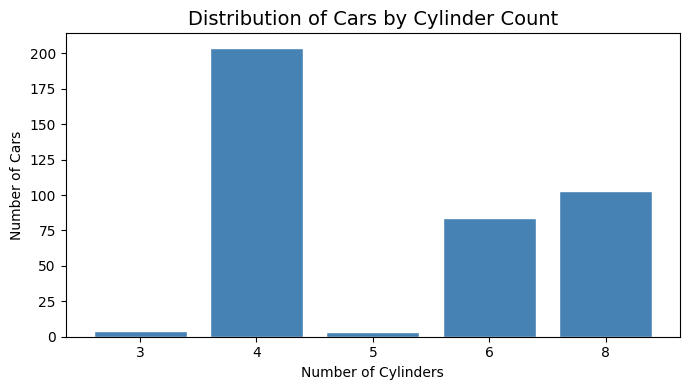

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

# Count occurrences of each cylinder value
cylinder_counts = df['cylinders'].value_counts().sort_index()

ax.bar(cylinder_counts.index.astype(str), cylinder_counts.values, color='steelblue', edgecolor='white')

ax.set_title('Distribution of Cars by Cylinder Count', fontsize=14)
ax.set_xlabel('Number of Cylinders')
ax.set_ylabel('Number of Cars')

plt.tight_layout()
plt.show()

## Step 6: Scatterplot - Horsepower vs. Weight

We expect a positive relationship here: heavier cars typically require more powerful engines. Each point is colored by region of origin to add a third layer of information. Rows with missing horsepower are excluded from this plot only.

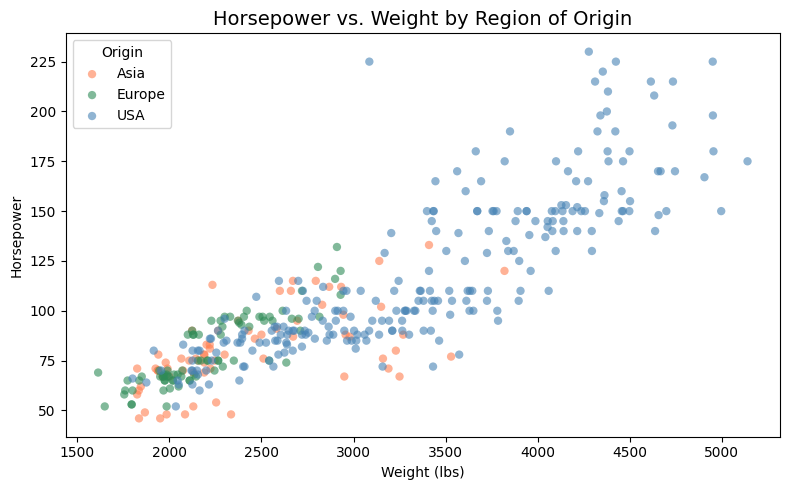

In [8]:
# Drop rows with NaN horsepower for this plot only
df_hp = df.dropna(subset=['horsepower'])

fig, ax = plt.subplots(figsize=(8, 5))

colors = {'USA': 'steelblue', 'Asia': 'coral', 'Europe': 'seagreen'}

for origin, group in df_hp.groupby('origin'):
    ax.scatter(
        group['weight'], group['horsepower'],
        label=origin,
        color=colors[origin],
        alpha=0.6,
        edgecolors='none'
    )

ax.set_title('Horsepower vs. Weight by Region of Origin', fontsize=14)
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Horsepower')
ax.legend(title='Origin')

plt.tight_layout()
plt.show()

## Step 7: Original Question - Exploratory Analysis

**Question:** Does fuel efficiency (MPG) improve over time, and does that trend
differ by region of origin?

The dataset spans model years 1970–1982 — a period that includes the 1973 oil crisis
and the 1979 energy crisis. We would expect MPG to generally increase over time
as manufacturers responded to fuel economy pressure. The question is whether
that response was uniform across American, Asian, and European manufacturers.

We use a seaborn lineplot with markers to show average MPG per model year,
broken out by origin.

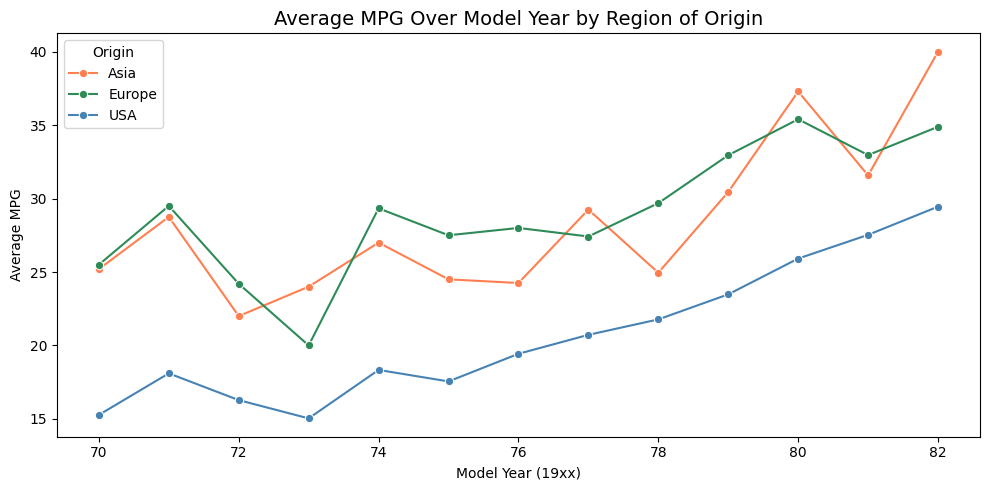

In [9]:
# Compute mean MPG per model year per origin
mpg_trend = df.groupby(['model_year', 'origin'])['mpg'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=mpg_trend,
    x='model_year',
    y='mpg',
    hue='origin',
    marker='o',
    palette={'USA': 'steelblue', 'Asia': 'coral', 'Europe': 'seagreen'},
    ax=ax
)

ax.set_title('Average MPG Over Model Year by Region of Origin', fontsize=14)
ax.set_xlabel('Model Year (19xx)')
ax.set_ylabel('Average MPG')
ax.legend(title='Origin')

plt.tight_layout()
plt.show()

## Answer

The line plot reveals several clear patterns:

- **All three regions improved MPG over time**, but the rate and consistency differ.
- **Asian cars consistently lead in fuel efficiency** across nearly every year,
  reflecting a design philosophy prioritizing economy from the start.
- **European cars are competitive with Asian cars** and show steady improvement.
- **USA cars start with the lowest MPG** but show the steepest improvement after 1974,
  which aligns with the regulatory pressure following the first oil crisis.
- The gap between USA and Asian/European cars narrows significantly by the early 1980s.

This suggests that fuel efficiency improvements in the dataset are partly
a reaction to external events (oil crises) rather than purely technological progress,
and that American manufacturers were slower to adapt than their foreign counterparts.

## Summary

| Step | Task | Method |
|---|---|---|
| 1 | Load data | `requests` + `str.split(None, 8)` |
| 2 | Inspect | `.info()`, `.isnull().sum()` |
| 3 | Confirm horsepower | `.dtype`, `.isnull().sum()` |
| 4 | Recode origin | `.map()` with dictionary |
| 5 | Bar chart (cylinders) | `matplotlib` bar |
| 6 | Scatterplot (HP vs weight) | `matplotlib` scatter by origin |
| 7 | MPG trend over time | `seaborn` lineplot by origin |